## Tatsächliche Reproduktion des Papers  
- sk fold NUR über train und validation  
- anschließend hyperparameter pro split berechnen (also je train/val split (5x))  
- Hyperparameter: NUR n_estimator in betracht ziehen
- nur auf single trainieren und anschließend auf grouped und binär maskieren. Ebenso wie auf s1st und sall maskieren   


In [2]:
import pyscrew
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.utils import shuffle 
from sklearn.preprocessing import LabelEncoder
from tabpfn import TabPFNClassifier
import time
import seaborn as sns
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import RandomOverSampler

To prepare the data, duplicates were first removed and missing time points in the time series
were linearly interpolated. The length of all time series was limited to 800 by truncation, with
shorter series being filled with zeros at the end. Furthermore, no features were extracted,
but only the torque measurements in an equidistant interval of 0.0012 sec. were used for
analysis  

somit kein angle oder gradient als zus. features 
torque = np.array(df['torque_values'].tolist())
    angle = np.array(df['angle_values'].tolist())
    gradient = np.array(df['gradient_values'].tolist())
    X = np.hstack([torque, angle, gradient])

sondern nur torque als X = np.array(df['torque_vales'].tolist())


In [3]:
#Laden der Daten mit Funktion auf Target Length 800 und train test data split 
def prep_pyscrew(scenario="s02", target_length=800, strategy="binary"):
    #Wie in github repo empfholen laden
    data = pyscrew.get_data(
    scenario=scenario,  # or "s04" or "s04_assembly-conditions-2"
    cache_dir="~/.cache/pyscrew", # Specify custom directory (default: src/pyscrew/downloads)
    force_download=False,  # Force re-download even if cached
    handle_duplicates="first",  # How to handle duplicate time points
    handle_missings="mean",  # How to handle missing values
    target_length=target_length,  # Target length for normalization
)
    df = pd.DataFrame(data)
    #Benötigte Features: torque_values angle_values gradient_values
    if not all(col in df.columns for col in ['torque_values','angle_values','gradient_values']):
        print("Fehler: mindestens einer der drei benötigten Features fehlen in X")
        raise ValueError("Fehler: mindestens einer der drei benötigten Features fehlen in X")
    X = np.array(df['torque_values'].tolist())
    
    #label
    class_values = df['class_values'].values
    le = LabelEncoder()
    #für später S1st unterscheidung
    usage = df['workpiece_usage'].values

    #labels binär gestalten
    if strategy == "binary":
        y = np.array([0 if str(l).startswith('0') else 1 for l in class_values])
        le.fit(["OK", "NOK"])
    elif strategy == "grouped":
        #Muss ich encodieren am besten von Anomalieart -> Zahlen (LabelEncoder von sklearn)
        y_strings = []
        for l in class_values:
            if l.startswith('0'):
                y_strings.append("0_Kontrollgruppe")
            elif l.startswith('1'):
                y_strings.append("1_Fehlerhafte_Schraube")
            elif l.startswith('2'):
                y_strings.append("2_Fehlerhaftes_Bauteil")
            elif l.startswith('3'):
                y_strings.append("3_Lochfehler")
            elif l.startswith('4'):
                y_strings.append("4_Fehlerhafte Umgebung")
            elif l.startswith('5'):
                y_strings.append("5_Fehlerhafte_Torque/Angle_Variationen")
            elif l.startswith('6'):
                y_strings.append("6_Oberflächenfehler")
        #Umwandeln in Zahlen (0,1,2,3,4,5) für die grouped labels
        y = le.fit_transform(y_strings)
        print(f"Gruppen: {le.classes_} und somit {len(y)} Klassen")
    elif strategy == "single":
        #aus 001_control_group, 101_screw_fault, 201_component_fault, 301_hole_fault, 401_surface_env, 501_process_variations -> 0,1,2,3,4,5,......
        y = le.fit_transform(class_values)
        print(f"Single labels: {len(le.classes_)} Klassen")
        
    # Wichtig - shuffeln (der SCHRAUBVORGÄNGE(!) und nicht der einzelnen Daten Luke!)
    X, y, usage = shuffle(X, y, usage, random_state=42)
    return X,y,usage,le


In [4]:
#Reproduktion aus dem Paper - nur single labels
scenario = "s02"
strategie = "single"

all_final_results = [] #spätere DF

#gesamte daten laden in x
x_all, y_all, usage, le = prep_pyscrew(scenario=scenario, strategy=strategie)
# Train / dev Split 80/20
#X_train, X_val, y_train, y_val, usage_train, usage_val = train_test_split(x_all, y_all, usage, test_size=0.2, stratify=y_all, random_state=42)
# split machen mit kfold - riesiger fehler von mir

2026-03-13 15:35:15 - INFO - pyscrew.main - Starting data retrieval for scenario: s02 (surface-friction)
2026-03-13 15:35:15 - INFO - pyscrew.pipeline.loading - Using cache directory (absolute): C:\Users\Patrick\.cache\pyscrew
2026-03-13 15:35:15 - INFO - pyscrew.pipeline.loading - Beginning data extraction for scenario 's02_variations-in-surface-friction.zip' (force=False)
2026-03-13 15:35:15 - INFO - pyscrew.pipeline.loading - Verifying MD5 checksum for 's02_variations-in-surface-friction.zip'...
2026-03-13 15:35:15 - INFO - pyscrew.pipeline.loading - Checksum verification successful for 's02_variations-in-surface-friction.zip' (MD5: 0bc948a6e8c6e83f72dbe36973131558)
2026-03-13 15:35:15 - INFO - pyscrew.pipeline.loading - Using existing verified file 's02_variations-in-surface-friction.zip' at: C:\Users\Patrick\.cache\pyscrew\archives\s02_variations-in-surface-friction.zip
2026-03-13 15:35:16 - INFO - pyscrew.pipeline.loading - Using existing extracted data for scenario 's02_variatio

2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_missings - Completed missing interpolation using 'mean' method (interval=0.0012)
2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_missings - Processed 12,500 series with 8,619,982 total points
2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_missings - Found gaps - min: 0.0012s, max: 0.1128s, avg: 0.0013s
2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_missings - Added 484,205 points (+5.62% of total)
2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_missings - Average 38.7 points added per series


2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_lengths - Starting to apply equal lengths.
2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'target_length' : 800
2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'padding_value' : 0.0
2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'padding_position' : post
2026-03-13 15:38:54 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'cutoff_position' : post
2026-03-13 15:38:55 - INFO - pyscrew.pipeline.transformers.handle_lengths - Finished applying equal lengths to the screw driving data.
2026-03-13 15:38:55 - INFO - pyscrew.pipeline.transformers.handle_lengths - - Total screw runs loaded:	12500
2026-03-13 15:38:55 - INFO - pyscrew.pipeline.transformers.handle_lengths - - Average change of length:	728.33 -> 800.00
2026-03-13 15:38:55 - INFO - pyscrew.pipeline.transformers.handle_lengths - - Total points before normalization:	9,104,

In [17]:
print(np.unique(y_all))

[0 1 2 3 4 5 6 7]


In [77]:
print(x_all.shape) #test zweck x=torque

(12500, 800)


### Ablauf
-kfold initielisieren und über x_all  yall laufen lassen  und in folds speichern | SKfold teilt es automatisch stratified in n_splits -1 training + 1 val data auf  
- schleife über fold für train und val data in enumerate kfolds  
- gridsearch ausführen über diese schleife und params testen. Scoring metriken ausgeben und scoren nach f1 macro avg --> siehe https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html  
- ausgabe tabelle oder bestmodel params best score für hyperparametertuning.  
- für training best_rf(**params) erstellen mit ausgabe von metriken (ACC +std ,precision +std , recall +std , f1macro avg+ std)  (siehe gridsearchcv web)  
- predicting x_val für gleiche metriken (ACC +std ,precision +std , recall +std , f1macro avg+ std)

--> Ziel: exakte reproduktion von west - nahe seiner ergebnisse

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(cv.split(x_all, y_all))  

for fold_idx, (train_idx, val_idx) in enumerate(folds): #für fold 1 bis 5, train idx und val idx bekommen, damit ich die daten ansprechen kann. Erste iteration: fold_idx = 0, train_idx = [0,1,2,...], val_idx = [100,101,...]
    print(f"fold {fold_idx+1}")
    print(f"training data :{len(train_idx)} {len(train_idx)/len(x_all)*100}%")
    print(f"validation data :{len(val_idx)} {len(val_idx)/len(x_all)*100}%")
    
#sind listen von indize, um ein train und zugehörige val data anzusprechen, muss ich  in der schleife machen

fold 1
training data :10000 80.0%
validation data :2500 20.0%
fold 2
training data :10000 80.0%
validation data :2500 20.0%
fold 3
training data :10000 80.0%
validation data :2500 20.0%
fold 4
training data :10000 80.0%
validation data :2500 20.0%
fold 5
training data :10000 80.0%
validation data :2500 20.0%


In [29]:
params = {"n_estimators": [675,700,725, 750, 775]}
fold_results = []
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"Fold {fold_idx + 1}")
    
    #train data ansprechen durch deren indize
    X_train, y_train = x_all[train_idx], y_all[train_idx]
    
    #hyperparameter bestimmung für n_estimator
    grid = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
        param_grid=params,
        scoring="f1_macro",  #F1 Macro als metrik - wichtig
        cv=3,  
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    best_score = grid.best_score_
    
    #Ergebnisse in foldresults hinzufügen
    fold_results.append({
        "fold": fold_idx + 1,
        "best_params": best_params,
        "best_score": best_score
    })
#als df ausgeben und mean und std berechnen über die folds
results_df = pd.DataFrame(fold_results)
print(results_df)

mean_f1_macro = results_df["best_score"].mean() #auch meantestscore
std_f1_macro = results_df["best_score"].std() #auch std test score 

print(f"Mean macro f1 über alle Folds: {mean_f1_macro} *100")
print(f"Std macro f1 über alle Folds: {std_f1_macro}*100")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
   fold            best_params  best_score
0     1  {'n_estimators': 725}    0.329647
1     2  {'n_estimators': 700}    0.336497
2     3  {'n_estimators': 675}    0.339534
3     4  {'n_estimators': 775}    0.336956
4     5  {'n_estimators': 675}    0.339775
Mean macro f1 über alle Folds: 0.33648165712572614 *100
Std macro f1 über alle Folds: 0.004095781347037284*100


## Durchläufe hyperparameter:
Round 1: best params 700 | macro_f1 33,59% std 0.45%  
-> suchen in richtung >= 700   params = {"n_estimators": [700, 800, 900, 1000, 1200]}
Round 2: best params 800 / 700 | macro_f1 33,9% std 0.0060%  
-> suchen in richtung ~ 700
Round 3: beste params == 700 (siehe grid cv results) 

In [30]:
print(grid.best_estimator_)
print(grid.best_params_)

RandomForestClassifier(class_weight='balanced', n_estimators=675,
                       random_state=42)
{'n_estimators': 675}


In [31]:
grid_results = pd.DataFrame(grid.cv_results_)
grid_results
#params mit 550 haben 0.02 weniger std und nur 0.003 weniger mean score. Somit macht 550 noch mehr sinn weil konsistenter über mehrere cv

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,101.494850,0.763346,1.348217,0.068605,675,{'n_estimators': 675},0.338345,0.334628,0.346350,0.339775,0.004891,1
1,105.235579,1.410365,1.548778,0.139330,700,{'n_estimators': 700},0.338333,0.335366,0.343338,0.339012,0.003290,3
2,109.042613,0.704124,1.401920,0.060007,725,{'n_estimators': 725},0.338869,0.334871,0.344593,0.339444,0.003990,2
3,111.396258,0.965398,1.115779,0.160944,750,{'n_estimators': 750},0.337875,0.334801,0.344040,0.338905,0.003842,4
4,93.016868,1.127828,0.737336,0.083773,775,{'n_estimators': 775},0.337406,0.334609,0.344575,0.338864,0.004197,5


## Prediction xval  
usage filter: workpiece_usage mitnehmen beim split (usage bei meiner funktion) | folds sind lediglich indize, deshalb innerhalb loop übergeben  
labelstrategie filter: y_val labels vorhanden. 0,1,2,3,...7 filtern nach binary und grouped. grouped 0 -> 0; 1->1; 2,3 -> 2; 4,5 -> 3; 6,7 -> 4

In [22]:
params = {"n_estimators": 700} #beste war 550 bzw 500 bei nur feature torque | 700 bei torque gradient angle
fold_results = []
for fold_idx, (train_idx, val_idx) in enumerate(folds):    
    #train data ansprechen durch deren indize
    X_val, y_val, usage_val = x_all[val_idx], y_all[val_idx], usage[val_idx]
    X_train, y_train, usage_train = x_all[train_idx], y_all[train_idx], usage[train_idx]
    
    #hyperparameter bestimmung für n_estimator
    best_rf = RandomForestClassifier(**params, random_state=42, class_weight="balanced")
    best_rf.fit(X_train, y_train)
    y_pred = best_rf.predict(X_val)
    
    fold_results.append({
        "fold": fold_idx+1,
        "workpiece_usage": usage_val,
        "True_label": y_val,
        "Pred_label": y_pred
    })
#als df ausgeben und mean und std berechnen über die folds

In [33]:
print(fold_results)

[{'fold': 1, 'workpiece_usage': array([4, 6, 4, ..., 7, 3, 8], shape=(2500,)), 'True_label': array([5, 1, 1, ..., 6, 7, 2], shape=(2500,)), 'Pred_label': array([1, 0, 1, ..., 1, 1, 2], shape=(2500,))}, {'fold': 2, 'workpiece_usage': array([15, 23,  6, ...,  3,  3,  5], shape=(2500,)), 'True_label': array([4, 6, 2, ..., 3, 7, 0], shape=(2500,)), 'Pred_label': array([0, 1, 6, ..., 4, 6, 0], shape=(2500,))}, {'fold': 3, 'workpiece_usage': array([ 8, 24, 19, ...,  8, 22,  5], shape=(2500,)), 'True_label': array([0, 0, 0, ..., 0, 2, 3], shape=(2500,)), 'Pred_label': array([1, 6, 0, ..., 1, 0, 5], shape=(2500,))}, {'fold': 4, 'workpiece_usage': array([17, 24,  7, ..., 16, 24, 22], shape=(2500,)), 'True_label': array([7, 2, 0, ..., 0, 3, 2], shape=(2500,)), 'Pred_label': array([5, 1, 0, ..., 0, 5, 7], shape=(2500,))}, {'fold': 5, 'workpiece_usage': array([24,  2, 17, ..., 17, 10,  8], shape=(2500,)), 'True_label': array([6, 1, 2, ..., 0, 4, 7], shape=(2500,)), 'Pred_label': array([6, 0, 7, ..

In [34]:
print(x_all.shape)

(12500, 2400)


Filter implementieren für workpiece usage als auch für verschiedene label  
workpiece usage mask auf == 0 setzen  
label logik muss implementiert werden, mit schleife .startswith("")

In [23]:
def pred_filter(fold_results, label="binary", usage1st = True):
    metriken = {"Accuracy": [], "Precision": [], "Recall": [], "F1_macro": []}
    for fold in fold_results:
        y_val = fold["True_label"]
        y_pred = fold["Pred_label"]
        usage_val = fold["workpiece_usage"]
        
        if usage1st == True:
            usage_filter = usage_val== 0
            y_val_filtered = y_val[usage_filter]
            y_pred_filtered = y_pred[usage_filter]
        else:
            y_val_filtered = y_val
            y_pred_filtered = y_pred
        
        if label == "binary":
            y_val_binary = []
            y_pred_binary = []
            for l in y_val_filtered:
                if str(l).startswith('0'):
                    y_val_binary.append(0)
                else:
                    y_val_binary.append(1)
            for l in y_pred_filtered:
                if str(l).startswith('0'):
                    y_pred_binary.append(0)
                else:
                    y_pred_binary.append(1)
            y_val_filtered = np.array(y_val_binary)
            y_pred_filtered = np.array(y_pred_binary)
        elif label == "grouped":
            y_val_group =[]
            y_pred_group=[]
            for l in y_val_filtered:
                if str(l).startswith('0'):
                    y_val_group.append(0)
                elif str(l).startswith('1'):
                    y_val_group.append(1)
                elif str(l).startswith('2') or str(l).startswith('3'):
                    y_val_group.append(2)
                elif str(l).startswith('4') or str(l).startswith('5'):
                    y_val_group.append(3)
                elif str(l).startswith('6') or str(l).startswith('7'):
                    y_val_group.append(4)
            for l in y_pred_filtered:
                if str(l).startswith('0'):
                    y_pred_group.append(0)
                elif str(l).startswith('1'):
                    y_pred_group.append(1)
                elif str(l).startswith('2') or str(l).startswith('3'):
                    y_pred_group.append(2)
                elif str(l).startswith('4') or str(l).startswith('5'):
                    y_pred_group.append(3)
                elif str(l).startswith('6') or str(l).startswith('7'):
                    y_pred_group.append(4)
            y_val_filtered = np.array(y_val_group)
            y_pred_filtered = np.array(y_pred_group)
        elif label == "single":
            y_val_filtered = np.array(y_val_filtered)
            y_pred_filtered = np.array(y_pred_filtered)
        #metriken bereich: acc prec recall f1 mit bib
        metriken["Accuracy"].append(accuracy_score(y_val_filtered, y_pred_filtered))
        metriken["Precision"].append(precision_score(y_val_filtered, y_pred_filtered, average="binary")) #average methode binary
        metriken["Recall"].append(recall_score(y_val_filtered, y_pred_filtered, average="binary")) #average nethode binary
        metriken["F1_macro"].append(f1_score(y_val_filtered, y_pred_filtered, average="binary")) #averme methode binary

    stats = {"Accuracy_mean": np.mean(metriken["Accuracy"]),"Accuracy_std": np.std(metriken["Accuracy"]), "Precision_mean": np.mean(metriken["Precision"]), "Precision_std": np.std(metriken["Precision"]), "Recall_mean": np.mean(metriken["Recall"]), "Recall_std": np.std(metriken["Recall"]), "F1_macro_mean": np.mean(metriken["F1_macro"]), "F1_macro_std": np.std(metriken["F1_macro"])}
    for i in stats:
        if i != "Accuracy_std" and i != "Precision_std" and i != "Recall_std" and i != "F1_macro_std":
            stats[i] *= 100
    df = pd.DataFrame([stats])
    return df


# ! Tatsächlich - bei average method hätte ich bei average methode = "binary" wählen müssne und nicht average !
Finale Werte hier - basierend auf single siehe aber auch bei eigenem model. Ggf bessere parameter und bei binary aufjedenfall möglich bessere werte zu erzielen, mit threshold. Davon wurde aber glaub nichts explizit erwähnt im paper

In [ ]:
#verschiedene labelstrategien und usage1std v usageall im vergleich als df
df_binary_s1st = pred_filter(fold_results, label="binary", usage1st=True)
df_binary_all = pred_filter(fold_results, label="binary", usage1st=False)
df_grouped_s1st = pred_filter(fold_results, label="grouped", usage1st=True)
df_grouped_all = pred_filter(fold_results, label="grouped", usage1st=False)
df_single_s1st = pred_filter(fold_results, label="single", usage1st=True)
df_single_all = pred_filter(fold_results, label="single", usage1st=False)

In [25]:
# Fehler erkannt: ich habe bei label="single" angegeben statt binary - Ergebnis nicht repräsentativ für X=angle,gradient und torque
df_binary_s1st
# West: 82,40 ± 0.21 87.33 ± 0.03 91.25 ± 0.03 89.16 ± 0.10

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,81.424866,0.037373,92.019647,0.024496,84.022618,0.027654,87.830685,0.024978


In [26]:
df_binary_all
# West: 80.53 ± 0.00 81.42 ± 0.00 98.03 ± 0.00 88.96 ± 0.00

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,73.528,0.004992,88.871061,0.005448,76.5,0.011718,82.213894,0.004891


In [71]:
df_grouped_s1st
# West: 60.20 ± 0.25 61.14 ± 0.33 60.20 ± 0.25 59.46 ± 0.30

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,63.938779,0.028661,65.979278,0.036527,64.160131,0.021827,62.991372,0.025628


In [72]:
df_grouped_all
# West: 48.85 ± 0.00 48.87 ± 0.00 48.85 ± 0.00 47.51 ± 0.00

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,47.432,0.007434,49.747656,0.011416,47.432,0.007434,47.197858,0.008481


In [73]:
df_single_s1st
# West: 52.40 ± 0.12 53.38 ± 0.21 52.40 ± 0.12 50.89 ± 0.15

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,54.387454,0.023885,55.044914,0.047532,53.760952,0.037718,51.593996,0.031978


In [74]:
df_single_all
# West:  ACC 37.72 ± 0.01 Prec 37.09 ± 0.02 Rec 37.73 ± 0.01 F1-Score 36.39 ± 0.01

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,38.928,0.005024,38.70224,0.010268,34.94,0.0068,35.202991,0.008224


# Ausschließlich X = Torque als featureeingabe

In [79]:
params = {"n_estimators": [70,80,90,100,110]}
fold_results = []
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"Fold {fold_idx + 1}")
    
    #train data ansprechen durch deren indize
    X_train, y_train = x_all[train_idx], y_all[train_idx]
    
    #hyperparameter bestimmung für n_estimator
    grid = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
        param_grid=params,
        scoring="f1_macro",  #F1 Macro als metrik - wichtig
        cv=3,  
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    best_score = grid.best_score_
    
    #Ergebnisse in foldresults hinzufügen
    fold_results.append({
        "fold": fold_idx + 1,
        "best_params": best_params,
        "best_score": best_score
    })
#als df ausgeben und mean und std berechnen über die folds
results_df = pd.DataFrame(fold_results)
print(results_df)

mean_f1_macro = results_df["best_score"].mean() #auch meantestscore
std_f1_macro = results_df["best_score"].std() #auch std test score 

print(f"Mean macro f1 über alle Folds: {mean_f1_macro} *100")
print(f"Std macro f1 über alle Folds: {std_f1_macro}*100")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
   fold            best_params  best_score
0     1  {'n_estimators': 110}    0.328784
1     2  {'n_estimators': 100}    0.332776
2     3  {'n_estimators': 110}    0.332347
3     4  {'n_estimators': 100}    0.333226
4     5  {'n_estimators': 110}    0.333843
Mean macro f1 über alle Folds: 0.33219527701338925 *100
Std macro f1 über alle Folds: 0.001985767290223986*100


In [82]:
params = {"n_estimators": 100} #beste war 550 bzw 500 bei nur feature torque | 700 bei torque gradient angle
fold_results = []
for fold_idx, (train_idx, val_idx) in enumerate(folds):    
    #train data ansprechen durch deren indize
    X_val, y_val, usage_val = x_all[val_idx], y_all[val_idx], usage[val_idx]
    X_train, y_train, usage_train = x_all[train_idx], y_all[train_idx], usage[train_idx]
    
    #hyperparameter bestimmung für n_estimator
    best_rf = RandomForestClassifier(**params, random_state=42, class_weight="balanced")
    best_rf.fit(X_train, y_train)
    y_pred = best_rf.predict(X_val)
    
    fold_results.append({
        "fold": fold_idx+1,
        "workpiece_usage": usage_val,
        "True_label": y_val,
        "Pred_label": y_pred
    })
#als df ausgeben und mean und std berechnen über die folds

In [83]:
#verschiedene labelstrategien und usage1std v usageall im vergleich als df
df_binary_s1st = pred_filter(fold_results, label="binary", usage1st=True)
df_binary_all = pred_filter(fold_results, label="binary", usage1st=False)
df_grouped_s1st = pred_filter(fold_results, label="grouped", usage1st=True)
df_grouped_all = pred_filter(fold_results, label="grouped", usage1st=False)
df_single_s1st = pred_filter(fold_results, label="single", usage1st=True)
df_single_all = pred_filter(fold_results, label="single", usage1st=False)

In [84]:
df_binary_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,82.030565,0.045011,72.5835,0.064181,77.916294,0.074947,74.422639,0.068871


In [85]:
df_binary_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,73.936,0.002924,64.488264,0.00492,69.235,0.010846,65.517202,0.005084


In [86]:
df_grouped_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,61.626546,0.040135,61.166529,0.049607,61.202773,0.049341,60.248375,0.048491


In [88]:
df_grouped_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,46.472,0.005254,48.129314,0.006478,46.472,0.005254,46.335727,0.004752


In [89]:
df_single_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,50.976382,0.032244,48.853693,0.026387,50.219785,0.041603,48.179351,0.0315


In [90]:
df_single_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,37.904,0.005482,36.328136,0.006452,34.045,0.005553,34.383324,0.00589


https://github.com/nikolaiwest/screw_data_loading/tree/main/screw_data_loading  --> datensatz für das projekt (Json dateien ohne preprocessing) 

PYSCREW: A COMPREHENSIVE DATASET COLLECTION FROM
INDUSTRIAL SCREW DRIVING EXPERIMENTS

"The PyScrew data is made available through Zenodo, an online
storage service for scientific data sets, and can be easily accessed either through GitHub (https://github.com/
nikolaiwest/pyscrew) or PyPi (https://pypi.org/project/pyscrew/), where we provide a custom library
designed for working with these datasets in Python."

Die sind identisch, mit Ausnahme das pyscrew bereit vorverarbeitet wurde und direkt zum Einsatz bereit gestellt worden ist. Der Datensatz von screw_data_loading ist noch in Rohform. Duplikate, messfehler, messzyklen unvollständig. 

# Test m binär irgendwie hochzupushen  
- Standardisierung bringt wie erwartet keine Besserung. Identische Werte - RF neutral gegenüberstandardisierung
- depth, min sampels leaf bringt alles nichts


letzter TEST: eigenes Modell für binär - diesmal aber korrekt! 


## Train/validation/testsplit ncv

TABPFN  
Tabelle je strategie (ncv rf 60 20 20, baseline(rf)), tabpfn ncv

In [27]:
#Reproduktion aus dem Paper - nur single labels
scenario = "s02"
strategie = "single"

all_final_results = [] #spätere DF

#gesamte daten laden in x
x_all, y_all, usage, le = prep_pyscrew(scenario=scenario, strategy=strategie)

2026-03-13 09:00:48 - INFO - pyscrew.main - Starting data retrieval for scenario: s02 (surface-friction)
2026-03-13 09:00:48 - INFO - pyscrew.pipeline.loading - Using cache directory (absolute): C:\Users\Patrick\.cache\pyscrew
2026-03-13 09:00:48 - INFO - pyscrew.pipeline.loading - Beginning data extraction for scenario 's02_variations-in-surface-friction.zip' (force=False)
2026-03-13 09:00:48 - INFO - pyscrew.pipeline.loading - Verifying MD5 checksum for 's02_variations-in-surface-friction.zip'...
2026-03-13 09:00:48 - INFO - pyscrew.pipeline.loading - Checksum verification successful for 's02_variations-in-surface-friction.zip' (MD5: 0bc948a6e8c6e83f72dbe36973131558)
2026-03-13 09:00:48 - INFO - pyscrew.pipeline.loading - Using existing verified file 's02_variations-in-surface-friction.zip' at: C:\Users\Patrick\.cache\pyscrew\archives\s02_variations-in-surface-friction.zip
2026-03-13 09:00:49 - INFO - pyscrew.pipeline.loading - Using existing extracted data for scenario 's02_variatio

2026-03-13 09:02:50 - INFO - pyscrew.pipeline.transformers.handle_missings - Completed missing interpolation using 'mean' method (interval=0.0012)
2026-03-13 09:02:50 - INFO - pyscrew.pipeline.transformers.handle_missings - Processed 12,500 series with 8,619,982 total points
2026-03-13 09:02:50 - INFO - pyscrew.pipeline.transformers.handle_missings - Found gaps - min: 0.0012s, max: 0.1128s, avg: 0.0013s
2026-03-13 09:02:50 - INFO - pyscrew.pipeline.transformers.handle_missings - Added 484,205 points (+5.62% of total)
2026-03-13 09:02:50 - INFO - pyscrew.pipeline.transformers.handle_missings - Average 38.7 points added per series


2026-03-13 09:02:51 - INFO - pyscrew.pipeline.transformers.handle_lengths - Starting to apply equal lengths.
2026-03-13 09:02:51 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'target_length' : 800
2026-03-13 09:02:51 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'padding_value' : 0.0
2026-03-13 09:02:51 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'padding_position' : post
2026-03-13 09:02:51 - INFO - pyscrew.pipeline.transformers.handle_lengths - - 'cutoff_position' : post
2026-03-13 09:02:52 - INFO - pyscrew.pipeline.transformers.handle_lengths - Finished applying equal lengths to the screw driving data.
2026-03-13 09:02:52 - INFO - pyscrew.pipeline.transformers.handle_lengths - - Total screw runs loaded:	12500
2026-03-13 09:02:52 - INFO - pyscrew.pipeline.transformers.handle_lengths - - Average change of length:	728.33 -> 800.00
2026-03-13 09:02:52 - INFO - pyscrew.pipeline.transformers.handle_lengths - - Total points before normalization:	9,104,

In [7]:
#NCV inner und outer cv erstellen
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {"n_estimators": [80, 90, 100, 110, 120]}

In [ ]:
grid = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
        param_grid=params,
        scoring="f1_macro",
        cv=inner_cv,  
        n_jobs=-1
    )

inner_nested_cv_results= []
inner_nested_best_score= []
inner_nested_best_params= []
inner_nested_test_score = []

for train_index, test_index in outer_cv.split(x_all, y_all):
    X_train, X_test = x_all[train_index], x_all[test_index]
    y_train, y_test = y_all[train_index], y_all[test_index]

    grid.fit(X_train, y_train)
    inner_nested_cv_results.append(grid.cv_results_)
    inner_nested_best_score.append(grid.best_score_)
    inner_nested_best_params.append(grid.best_params_)

    inner_nested_test_score.append(grid.score(X_test, y_test))

In [7]:
np.mean(inner_nested_test_score)

np.float64(0.3443911996263262)

In [ ]:
cv_results_dfs = [pd.DataFrame(result) for result in inner_nested_cv_results]
#df erstellen für alle cv ergebnisse jeder iteration
all_cv_results_df = pd.concat(cv_results_dfs, ignore_index=True)
all_cv_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,8.547143,0.166491,0.042751,0.001661,80,{'n_estimators': 80},0.324715,0.335945,0.325484,0.338829,0.335449,0.332084,0.005824,5
1,9.605265,0.135038,0.046343,0.002008,90,{'n_estimators': 90},0.330347,0.341767,0.326585,0.352845,0.332460,0.336801,0.009455,1
2,10.725306,0.176082,0.063740,0.024845,100,{'n_estimators': 100},0.328909,0.340932,0.327469,0.343503,0.330653,0.334293,0.006598,2
3,11.593398,0.089358,0.050068,0.003209,110,{'n_estimators': 110},0.322777,0.339314,0.324952,0.355997,0.324621,0.333532,0.012703,4
4,11.843147,0.837502,0.046925,0.004312,120,{'n_estimators': 120},0.320085,0.345639,0.332379,0.345234,0.327003,0.334068,0.010068,3


In [9]:
inner_nested_best_params[0]

{'n_estimators': 90}

In [18]:
inner_nested_best_params

[{'n_estimators': 90},
 {'n_estimators': 100},
 {'n_estimators': 120},
 {'n_estimators': 100},
 {'n_estimators': 120}]

In [19]:
inner_nested_test_score

[0.35399062060823905,
 0.3404154850256713,
 0.3451298482918066,
 0.33626759698029984,
 0.34615244722561433]

In [ ]:
def pred_filter(fold_results, label="binary", usage1st = True):
    metriken = {"Accuracy": [], "Precision": [], "Recall": [], "F1_macro": []}
    if label =="binary":
        average_method="binary"
    elif label in ["single", "grouped"]:
        average_method="macro"
    
    for fold in fold_results:
        y_val = fold["True_label"]
        y_pred = fold["Pred_label"]
        usage_val = fold["workpiece_usage"]
        if usage1st == True:
            usage_filter = usage_val== 0
            y_val_filtered = y_val[usage_filter]
            y_pred_filtered = y_pred[usage_filter]
        else:
            y_val_filtered = y_val
            y_pred_filtered = y_pred
        if label == "binary":
            y_val_binary = []
            y_pred_binary = []
            for l in y_val_filtered:
                if str(l).startswith('0'):
                    y_val_binary.append(0)
                else:
                    y_val_binary.append(1)
            for l in y_pred_filtered:
                if str(l).startswith('0'):
                    y_pred_binary.append(0)
                else:
                    y_pred_binary.append(1)
            y_val_filtered = np.array(y_val_binary)
            y_pred_filtered = np.array(y_pred_binary)
        elif label == "grouped":
            y_val_group =[]
            y_pred_group=[]
            for l in y_val_filtered:
                if str(l).startswith('0'):
                    y_val_group.append(0)
                elif str(l).startswith('1'):
                    y_val_group.append(1)
                elif str(l).startswith('2') or str(l).startswith('3'):
                    y_val_group.append(2)
                elif str(l).startswith('4') or str(l).startswith('5'):
                    y_val_group.append(3)
                elif str(l).startswith('6') or str(l).startswith('7'):
                    y_val_group.append(4)
            for l in y_pred_filtered:
                if str(l).startswith('0'):
                    y_pred_group.append(0)
                elif str(l).startswith('1'):
                    y_pred_group.append(1)
                elif str(l).startswith('2') or str(l).startswith('3'):
                    y_pred_group.append(2)
                elif str(l).startswith('4') or str(l).startswith('5'):
                    y_pred_group.append(3)
                elif str(l).startswith('6') or str(l).startswith('7'):
                    y_pred_group.append(4)
            y_val_filtered = np.array(y_val_group)
            y_pred_filtered = np.array(y_pred_group)
        elif label == "single":
            y_val_filtered = np.array(y_val_filtered)
            y_pred_filtered = np.array(y_pred_filtered)
        #metriken:acc prec recall f1 mit bib
        metriken["Accuracy"].append(accuracy_score(y_val_filtered, y_pred_filtered))
        metriken["Precision"].append(precision_score(y_val_filtered, y_pred_filtered, average=average_method))
        metriken["Recall"].append(recall_score(y_val_filtered, y_pred_filtered, average=average_method))
        metriken["F1_macro"].append(f1_score(y_val_filtered, y_pred_filtered, average=average_method))

    stats = {"Accuracy_mean": np.mean(metriken["Accuracy"]),"Accuracy_std": np.std(metriken["Accuracy"]), "Precision_mean": np.mean(metriken["Precision"]), "Precision_std": np.std(metriken["Precision"]), "Recall_mean": np.mean(metriken["Recall"]), "Recall_std": np.std(metriken["Recall"]), "F1_macro_mean": np.mean(metriken["F1_macro"]), "F1_macro_std": np.std(metriken["F1_macro"])}
    for i in stats:
        if i != "Accuracy_std" and i != "Precision_std" and i != "Recall_std" and i != "F1_macro_std":
            stats[i] *= 100
    df = pd.DataFrame([stats])
    return df


In [20]:
final_param = {"n_estimators": 90}
fold_results = []

for train_index, test_index in outer_cv.split(x_all, y_all):
    X_train, X_test = x_all[train_index], x_all[test_index]
    y_train, y_test = y_all[train_index], y_all[test_index]
    usage_test = usage[test_index] 


    model = RandomForestClassifier(random_state=42, class_weight="balanced", **final_param)
    model.fit(X_train, y_train)
    y_pred_ncv = model.predict(X_test)
    
    fold_results.append({
        "fold": len(fold_results) + 1,
        "workpiece_usage": usage_test,
        "True_label": y_test,
        "Pred_label": y_pred_ncv
    })

fold_results_df = pd.DataFrame(fold_results)

In [23]:
#verschiedene labelstrategien und usage1std v usageall im vergleich als df
df_binary_s1st = pred_filter(fold_results, label="binary", usage1st=True)
df_binary_all = pred_filter(fold_results, label="binary", usage1st=False)
df_grouped_s1st = pred_filter(fold_results, label="grouped", usage1st=True)
df_grouped_all = pred_filter(fold_results, label="grouped", usage1st=False)
df_single_s1st = pred_filter(fold_results, label="single", usage1st=True)
df_single_all = pred_filter(fold_results, label="single", usage1st=False)

In [24]:
df_binary_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,81.211917,0.050062,91.997227,0.028831,83.735519,0.038507,87.660675,0.033382


In [26]:
df_binary_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,73.792,0.005068,88.793566,0.006589,76.96,0.006304,82.450782,0.003469


In [27]:
df_grouped_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,59.98185,0.048766,59.43575,0.051664,59.355669,0.051968,58.490904,0.050686


In [28]:
df_grouped_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,46.128,0.008234,47.773619,0.009033,46.128,0.008234,45.98969,0.007687


In [29]:
df_single_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,49.754297,0.041285,47.539004,0.019632,49.04307,0.035647,46.945513,0.025334


In [30]:
df_single_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,37.736,0.006111,36.224014,0.006758,33.92,0.0056,34.257669,0.005913


# TabPFN Ansatz

### Vorgehen:  
Ewig langes importieren verfahren; ebenfalls mit token. Leider nicht geklückt trotz korrekter anmeldung und lizenz. Daher local installiert und model path angegeben.
normal dauert es über 90 minuten ohne erfolg mit kfoldstratified  
mit reduzierten datensätze 12500 -> 5000 werden nicht alle klassen erkannt in den folds: ill defined prec / recall  
StandardScaler -> keinen unterschied bzw. keinen merkbaren
Klassenverteilung mit under und oversampling angepasst. Aber das hat nicht gut funktioniert: ill defined prec / recall
nun mit train test split und dann schauen was da möglich ist. Kein KFold -> train_testsplit mit stratify (class_weight falls möglich, bezweifle ich aber)  


featur importance aus rf zuvor bestimmen und dann die wichtigsten 50-100 features wählen. So das aus x_all= (12500, 800) -> x_reduced=(12500,100) rf-feature_importances_

In [14]:
fold_results = []

for train_index, test_index in outer_cv.split(x_all, y_all):
    X_train, X_test = x_all[train_index], x_all[test_index]
    y_train, y_test = y_all[train_index], y_all[test_index]
    usage_test = usage[test_index] 


    model = TabPFNClassifier(random_state=42, device="cuda", model_path="C:/Users/Patrick/AppData/Roaming/tabpfn/tabpfn-v2-classifier.ckpt", ignore_pretraining_limits=True)
    #model path da ich große probleme hatte das zu isntallieren. Und ignore pretatining limits da es auf anzahl features 500 begrenzt ist tabpfn
    model.fit(X_train, y_train)
    y_pred_tabpfn = model.predict(X_test)
    
    fold_results.append({
        "fold": len(fold_results) + 1,
        "workpiece_usage": usage_test,
        "True_label": y_test,
        "Pred_label": y_pred_tabpfn
    })

fold_results_df = pd.DataFrame(fold_results)

KeyboardInterrupt: 

### Test mit train test split wie da die ergebnisse sind 

In [22]:
X_reduced, _,y_reduced, _, usage_reduced, _=train_test_split(x_all, y_all, usage, train_size=5000, random_state=42, stratify=y_all)


In [23]:
from sklearn.metrics import roc_auc_score
X_train, X_test, y_train, y_test, usage_train, usage_test = train_test_split(
    X_reduced,
    y_reduced,
    usage_reduced,
    test_size=0.33,
    random_state=42,
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = TabPFNClassifier(random_state=42, device="cuda", model_path="C:/Users/Patrick/AppData/Roaming/tabpfn/tabpfn-v2-classifier.ckpt", ignore_pretraining_limits=True)
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)
prediction_probabilites = clf.predict_proba(X_test)
print("ROC AUC:", roc_auc_score(y_test, prediction_probabilites, multi_class="ovr"))

print("Accuracy:", accuracy_score(y_test, prediction))
print("Precision:", precision_score(y_test, prediction, average="macro"))
print("Recall:", recall_score(y_test, prediction, average="macro"))
print("F1 Score:", f1_score(y_test, prediction, average="macro"))


ROC AUC: 0.8203210984408946
Accuracy: 0.3878787878787879
Precision: 0.3740510304244212
Recall: 0.3462877293923312
F1 Score: 0.33890884020117196


In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.43      0.72      0.54       339
           1       0.40      0.38      0.39       327
           2       0.42      0.17      0.24       163
           3       0.38      0.47      0.42       169
           4       0.29      0.35      0.31       155
           5       0.41      0.15      0.22       182
           6       0.29      0.19      0.23       160
           7       0.38      0.34      0.36       155

    accuracy                           0.39      1650
   macro avg       0.37      0.35      0.34      1650
weighted avg       0.38      0.39      0.36      1650



In [ ]:
fold_results = [{
    "True_label":y_test,
    "Pred_label":prediction,
    "workpiece_usage": usage_test
}]

df_tabpfn_binary_s1st = pred_filter(fold_results, label="binary", usage1st=True)
df_tabpfn_binary_all = pred_filter(fold_results, label="binary", usage1st=False)
df_tabpfn_grouped_s1st = pred_filter(fold_results, label="grouped", usage1st=True)
df_tabpfn_grouped_all = pred_filter(fold_results, label="grouped", usage1st=False)
df_tabpfn_single_s1st = pred_filter(fold_results, label="single", usage1st=True) # hier kommt precision ill defined
df_tabpfn_single_all = pred_filter(fold_results, label="single", usage1st=False)

c:\Users\Patrick\miniconda3\envs\tabpfn_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
df_tabpfn_binary_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,76.388889,0.0,95.744681,0.0,75.0,0.0,84.11215,0.0


In [27]:
df_tabpfn_binary_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,74.727273,0.0,91.312384,0.0,75.362319,0.0,82.574175,0.0


In [30]:
df_tabpfn_grouped_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,54.166667,0.0,64.666667,0.0,53.572568,0.0,48.842557,0.0


In [31]:
df_tabpfn_grouped_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,46.484848,0.0,47.647035,0.0,46.309329,0.0,45.828089,0.0


In [32]:
df_tabpfn_single_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,40.277778,0.0,38.858902,0.0,38.308532,0.0,31.661503,0.0


In [33]:
df_tabpfn_single_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,38.787879,0.0,37.405103,0.0,34.628773,0.0,33.890884,0.0


In [6]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.5.1
True
12.1


In [8]:
print(x_all.shape)

(12500, 800)


In [9]:
print(X_reduced.shape)
print(y_reduced.shape)

(10000, 800)
(10000,)


In [10]:
y_reduced_uniq = pd.Series(y_reduced)
print(y_reduced_uniq.unique())

[1 4 3 2 5 6 0 7]


In [11]:
from imblearn.over_sampling import RandomOverSampler

"In order to use TabPFN, we need to split the data into a training and testing set. Note, that TabPFN works best for small sized datasets (less than 10k samples). On CPU, we can only use a very small number of training data points to fit the model. If you have a GPU, feel free to increase the number of samples."

https://shapiq.readthedocs.io/en/latest/notebooks/tabular_notebooks/explaining_tabpfn.html

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
fold_results = []

for fold,(train_index, test_index) in enumerate(outer_cv.split(x_all, y_all)):
    clf = TabPFNClassifier(
    model_path="C:/Users/Patrick/AppData/Roaming/tabpfn/tabpfn-v2-classifier.ckpt",
    device='cuda',
    random_state=42,
    ignore_pretraining_limits=True
    )

    start_time=time.time()
    X_train, X_test = x_all[train_index], x_all[test_index]
    y_train, y_test = y_all[train_index], y_all[test_index]
    usage_test = usage[test_index] 
    #oversampling damit werden die klassen mit weniger daten vergrößert - zum ausgleich der unbalanciertendaten. Im prnzip class_weight="balanced wie in rf
    RUS = RandomUnderSampler(random_state=42)
    X_train, y_train = RUS.fit_resample(X_train, y_train)

    #training und prediction
    clf.fit(X_train, y_train)
    y_pred_tabpfn = clf.predict(X_test)
    
    end_time = time.time()
    print(f"Fold {fold+1} {end_time-start_time} sekunden")
    print("Test labels:", np.unique(y_test, return_counts=True))
    print("Preds labels:", np.unique(y_pred_tabpfn, return_counts=True))
    
    fold_results.append({
        "fold": len(fold_results) + 1,
        "workpiece_usage": usage_test,
        "True_label": y_test,
        "Pred_label": y_pred_tabpfn
    })

fold_results_df = pd.DataFrame(fold_results)

1. Test: mit kfold stratified mit unterschiedlichen datasizes
2. Test: mit traintestsplit und ohne kfold


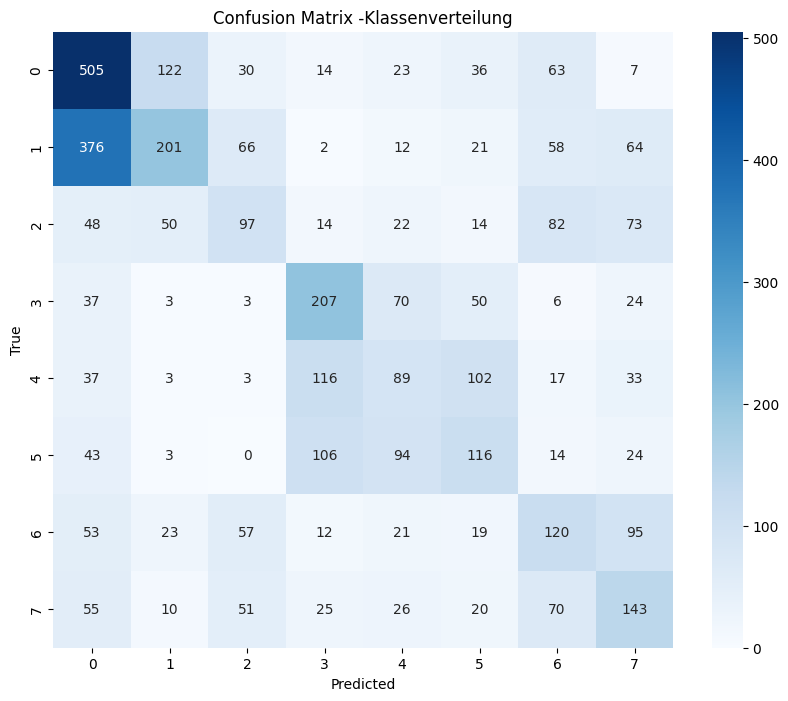

In [ ]:
all_true=[]
all_pred=[]

for label in fold_results:
    true_labels = label['True_label']
    pred_labels = label['Pred_label']
    all_true.extend(true_labels)
    all_pred.extend(pred_labels)

all_true= np.array(all_true)
all_pred= np.array(all_pred)
cm=confusion_matrix(all_true, all_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True,fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix -Klassenverteilung')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_tabpfn))

              precision    recall  f1-score   support

           0       0.40      0.57      0.47       160
           1       0.49      0.28      0.35       160
           2       0.36      0.24      0.29        80
           3       0.42      0.61      0.49        80
           4       0.28      0.29      0.29        80
           5       0.32      0.24      0.27        80
           6       0.28      0.31      0.30        80
           7       0.31      0.34      0.33        80

    accuracy                           0.37       800
   macro avg       0.36      0.36      0.35       800
weighted avg       0.38      0.37      0.36       800



In [ ]:
#verschiedene labelstrategien und usage1std v usageall im vergleich als df
df_binary_s1st = pred_filter(fold_results, label="binary", usage1st=True)
df_binary_all = pred_filter(fold_results, label="binary", usage1st=False)
df_grouped_s1st = pred_filter(fold_results, label="grouped", usage1st=True)
df_grouped_all = pred_filter(fold_results, label="grouped", usage1st=False)
df_single_s1st = pred_filter(fold_results, label="single", usage1st=True)
df_single_all = pred_filter(fold_results, label="single", usage1st=False)

c:\Users\Patrick\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Patrick\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Patrick\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
df_binary_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,79.752175,0.071544,92.46858,0.041547,81.853563,0.110714,86.185037,0.057779


In [ ]:
df_binary_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,76.4,0.014414,89.657504,0.013303,79.71875,0.015606,84.382425,0.009973


In [ ]:
df_grouped_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,51.908646,0.068246,52.831457,0.073919,51.524098,0.080847,50.05113,0.066401


In [ ]:
df_grouped_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,46.4,0.013191,46.905423,0.015839,46.4,0.013191,45.461411,0.014824


In [ ]:
df_single_s1st

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,41.562305,0.064174,41.782558,0.115349,38.308712,0.094544,36.157024,0.077499


In [ ]:
df_single_all

,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_macro_mean,F1_macro_std
0,36.95,0.008314,35.128026,0.009362,35.15625,0.006289,34.17849,0.007249
